In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated, operator
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv
load_dotenv()
model = ChatOpenAI()

In [2]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")
    
generator_llm = ChatOpenAI(model = 'gpt-4o')
evaluate_llm = ChatOpenAI(model = 'gpt-4o-mini')
optimizer_llm = ChatOpenAI(model = 'gpt-4o')
str_eval_llm = evaluate_llm.with_structured_output(TweetEvaluation)

In [3]:
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal['Approved', "Need Improvement"]
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]
    

In [4]:
def generate_tweet(state: TweetState)-> TweetState:
    message = [
        SystemMessage(content="You are a funny and clever Twitter influencer")
        ,HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english                              
                     """)]
    response = generator_llm.invoke(message).content
    return {'tweet': response, 'tweet_history':['response']}

def evaluate_tweet(state: TweetState)-> TweetState:
    message = [
        SystemMessage(content="You are a ruthless, no-laguh-given Twitter critic"),
        HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
    ]
    response = str_eval_llm.invoke(message)
    return {'evaluation': response.evaluation, 'feedback':response.feedback, 'feedback_history':[response.feedback]}


def operate_tweet(state: TweetState)-> TweetState:
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [5]:
def route_eval(state: TweetState):
    if state['evaluation'] =='Approved' or state['iteration']>=state['max_iteration']:
        return 'Approved'
    else:
        return 'Need Improvement'

In [6]:
graph = StateGraph(TweetState)

graph.add_node('generate',generate_tweet)
graph.add_node('evaluate',evaluate_tweet)
graph.add_node('operate',operate_tweet)

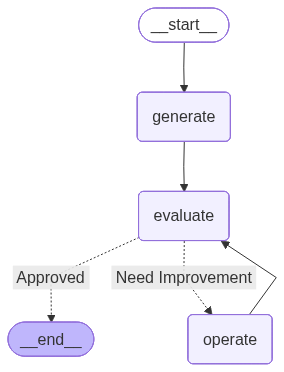

In [7]:
graph.add_edge(START, 'generate')
graph.add_edge('generate','evaluate')
graph.add_conditional_edges('evaluate', route_eval,{'Approved':END, 'Need Improvement':'operate'})
graph.add_edge('operate','evaluate')
wfs = graph.compile()
wfs

In [8]:
initial = {
    'topic':'six seven',
    'iteration':1,
    'max_iteration':4
}
final = wfs.invoke(initial)
final

{'topic': 'six seven',
 'tweet': '"\'Six Seven!\' they chanted in medieval times... right before stepping on a rogue Lego and inventing medieval curse words. #MedievalMissteps #LegoPain"',
 'evaluation': 'needs_improvement',
 'feedback': "While the concept of medieval people chanting before stepping on a Lego is somewhat original, the humor falls flat and lacks a genuine punch. The tweet is a bit too wordy and could be sharper to really grab attention. The playful mix of modern pain with a historical twist is interesting, but it doesn't evoke a strong enough reaction to make me smile or laugh. Additionally, it could use more succinctness to enhance its scroll-stopping potential.",
 'iteration': 4,
 'max_iteration': 4,
 'tweet_history': ['response',
  'Time-traveling to medieval land and explaining "Six Seven": It\'s the height of coolness, a way of life, and the last thing you yell in triumph... before you find that missing Lego with your bare foot! #TimeTravelProblems',
  '"Explained 

In [9]:
for t in final['tweet_history']:
    print(t)

response
Time-traveling to medieval land and explaining "Six Seven": It's the height of coolness, a way of life, and the last thing you yell in triumph... before you find that missing Lego with your bare foot! #TimeTravelProblems
"Explained 'Six Seven' in medieval times: it's the code of legends and the ultimate chant... right before you step on a hidden Lego and invent new words. #MedievalMissteps #LegoPain"
"'Six Seven!' they chanted in medieval times... right before stepping on a rogue Lego and inventing medieval curse words. #MedievalMissteps #LegoPain"


In [10]:
initial = {
    'topic':'Donald Trump on Iran War',
    'iteration':1,
    'max_iteration':4
}
final = wfs.invoke(initial)
for t in final['tweet_history']:
    print(t)

response
Trump planning an Iran war is like using a golf cart for a space mission: It rolls, but are we heading to Pluto or just teeing off at Mar-a-Lago's 9th hole? 🏌️‍♂️🚀 #GalacticGolfTour
When Trump plans for an Iran war, it's like launching a golf cart into space: you’re not sure if we’re pioneering interstellar travel or just cruising to the Mar-a-Lago snack bar. 🏌️‍♂️🚀 #AstroTeeOff
When Trump talks Iran war, it's like trying to book his golf tee time on Mars—high stakes, low logic, and we might just find a clubhouse on the moon. 🌌🏌️‍♂️ #ForeSightIntoMadness
